> # SECTION -3

<h4>

**Create quantum circuits**

--- 
- Construct basic quantum circuits
- **Construct dynamic circuits**
- Construct parameterized circuits
- Transpile and optimize circuits
---

</h4>

In [1]:
from platform import python_version
import qiskit
print("Python version ", python_version())
print(f"Qiskit version: {qiskit.__version__}")

Python version  3.13.5
Qiskit version: 2.5.0


In [1]:
from qiskit import QuantumCircuit

> ## Construct dynamic circuits

REFERENCE : https://quantum.cloud.ibm.com/docs/en/guides/classical-feedforward-and-control-flow

- you can measure qubits in the middle of a quantum circuit execution and 
- then perform classical logic operations within the circuit, based on the outcome of those mid-circuit measurements. 
- This process is also known as **classical feedforward** 

## if_test statement
The **if statement** is used to conditionally perform operations based on the value of a classical bit or register.

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#if_test

---
EXAMPLE 1:

---
we apply a Hadamard gate to a qubit and measure it. 

If the result is 1, then we apply an X gate on the qubit, which has the effect of flipping it back to the 0 state. 

We then measure the qubit again. The resulting measurement outcome should be 0 with 100% probability.


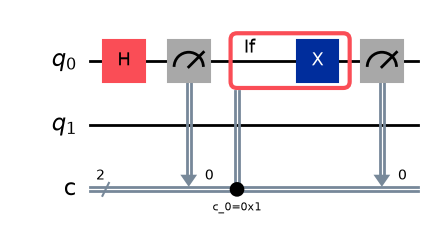

In [2]:
qc = QuantumCircuit(2,2)

qc.h(0)
qc .measure(0,0)
with qc.if_test((0, 1)):  # check if classical bit 0 is 1
    qc.x(0)
qc.measure(0,0)
qc.draw("mpl")

---
EXAMPLE 2:

---

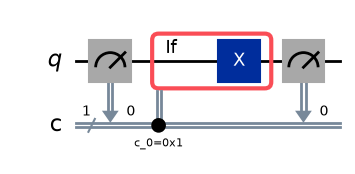

In [3]:

qc = QuantumCircuit(1,1)

qc.measure(0,0)

with qc.if_test((0, 1)):  # check if classical bit 0 is 1
    qc.x(0)
qc .measure(0,0)
qc.draw("mpl")

---
EXAMPLE 3:

---

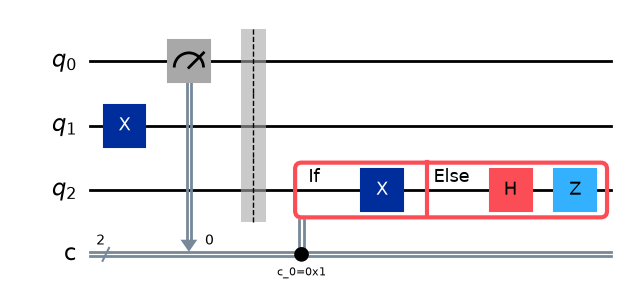

In [4]:

from qiskit.circuit import QuantumCircuit, Qubit, Clbit

qc = QuantumCircuit(3,2)

qc.x(1)
qc.measure(0, 0)

qc.barrier()

with qc.if_test((0, 1)) as else_:  # checks classical bit 0 is 0 
    qc.x(2)
with else_:
    qc.h(2)
    qc.z(2)

qc.draw("mpl")

---
EXAMPLE 4:

---

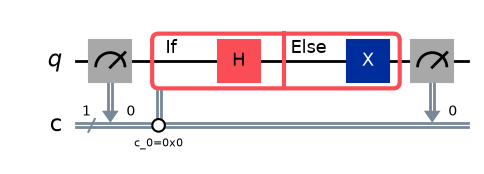

In [5]:
qc = QuantumCircuit(1,1)

qc.measure(0,0)
with qc.if_test((0, 0)) as else_:  # check if classical bit 0 is 0
    qc.h(0)
with else_:
    qc.x(0)
qc .measure(0,0)
qc.draw("mpl")

---
EXAMPLE 5: 

---

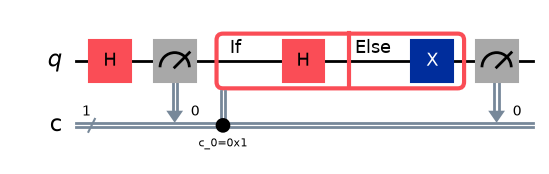

In [6]:
qc = QuantumCircuit(1,1)

qc.h(0)
qc.measure(0,0)
with qc.if_test((0, 1)) as else_:  # check if classical bit 0 is 1
    qc.h(0)
with else_:
    qc.x(0)
qc .measure(0,0)
qc.draw("mpl")

---
**For loop**:

---
for loop is used to iterate over a sequence of classical values and perform some operations during each iteration

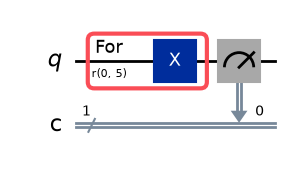

In [7]:
qc = QuantumCircuit(1,1)
with qc.for_loop(range(5)) as _:
    qc.x(0)
qc.measure(0, 0)

qc.draw("mpl")

---
**switch**:

---

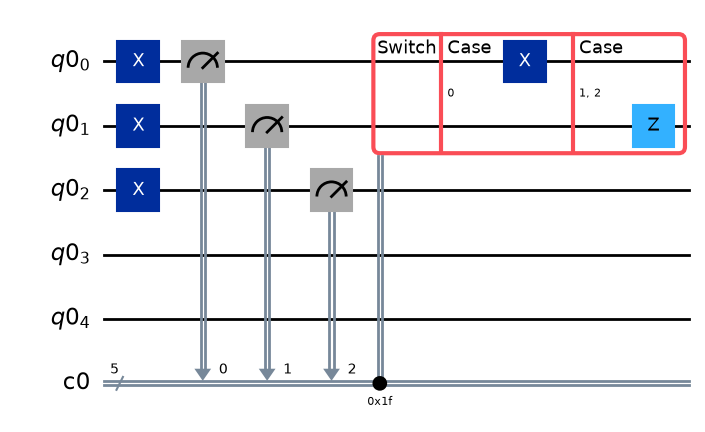

In [8]:
from qiskit.circuit import QuantumCircuit, ClassicalRegister, QuantumRegister
qreg = QuantumRegister(5)
creg = ClassicalRegister(5)
qc = QuantumCircuit(qreg, creg)
qc.x([0, 1, 2])
qc.measure([0, 1, 2], [0, 1, 2])

with qc.switch(creg) as case:
    with case(0):
        qc.x(0)
    with case(1, 2):
        qc.z(1)

qc.draw("mpl")

**Qiskit classical expression module** qiskit.circuit.classical 

contains an exploratory representation of runtime operations on classical values during circuit execution.
